In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import dismech_jax as djx


class Slinky1D(djx.System):
    """Simple 2-node 1D spring under displacement control."""

    l_k: jax.Array
    x_left: jax.Array
    x_right_initial: jax.Array
    x_right_final: jax.Array

    def get_q(self, _lambda: jax.Array, q0: jax.Array) -> jax.Array:
        """
        _lambda is in [0, 1] and parameterizes the imposed displacement path.

        Left node is fixed at x_left.
        Right node is prescribed by linear interpolation between
        x_right_initial and x_right_final.
        """
        x_right = (1.0 - _lambda) * self.x_right_initial + _lambda * self.x_right_final

        q = q0.at[0].set(self.x_left)
        q = q.at[1].set(x_right)
        return q

    def get_eps(self, q: jax.Array) -> jax.Array:
        return (q[1] - q[0]) / self.l_k - 1.0

    def get_E(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        eps = self.get_eps(q)
        return model(jnp.array([eps]))

    def get_F(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # No free DOFs in this 2-node fully prescribed toy problem.
        return jnp.zeros_like(q)

    def get_H(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        # Dummy Hessian for API compatibility.
        return jnp.eye(q.shape[0])

    def get_reaction_force(
        self, _lambda: jax.Array, q: jax.Array, model: eqx.Module, aux: None
    ) -> jax.Array:
        """
        Reaction force at the pulled (right) node.

        If your measured force has opposite sign convention,
        replace return dEdq[1] with return -dEdq[1].
        """
        dEdq = jax.grad(self.get_E, argnums=1)(_lambda, q, model, aux)
        return dEdq[1]


class SlinkyNN(eqx.Module):
    w1: jax.Array
    b1: jax.Array
    w2: jax.Array
    b2: jax.Array
    k0_raw: jax.Array
    which_case: str = None

    def __init__(self, key, K_initial=1.0, which_case = None):
        hidden_size = 10
        k1, k2 = jax.random.split(key)
        self.w1 = jax.random.normal(k1, (hidden_size, 1)) * 0.01
        self.b1 = jnp.zeros((hidden_size,))
        self.w2 = jax.random.normal(k2, (1, hidden_size)) * 0.01
        self.b2 = jnp.zeros((1,))
        self.k0_raw = jnp.array(K_initial)

        self.which_case = which_case

    def K_mlp(self, eps):
        h = jax.nn.softplus(self.w1 @ eps + self.b1)
        k_nn = jax.nn.softplus(self.w2 @ h + self.b2).squeeze()
        return k_nn

    def K_baseline(self):
        k0 = jax.nn.softplus(self.k0_raw)
        return k0
    
    # def get_K(self, eps): # signed correction
    #     h = jax.nn.softplus(self.w1 @ eps + self.b1)
    #     delta_raw = (self.w2 @ h + self.b2).squeeze()   # signed correction
    #     return jax.nn.softplus(self.k0_raw + delta_raw)

    def get_K(self, eps):
        if self.which_case == "only_mlp":
            return self.K_mlp(eps)
        elif self.which_case == "only_baseline":
            return self.K_baseline()
        else:
            return self.K_mlp(eps) + self.K_baseline()

    def __call__(self, eps):
        eps_scalar = eps.squeeze()
        return self.get_K(eps) * eps_scalar**2



In [2]:

# =========================================================
# Load data from your saved format
# =========================================================
data = np.load("slinky_pulling_force_data.npz")

force_truth = np.abs(jnp.array(data["F"]))  # shape (N,) # tension, data is reaction so it is opposite sign
initial_last_node_x = float(data["initial_last_node_x"])
final_last_node_x = float(data["final_last_node_x"])

num_steps = force_truth.shape[0]

# Since displacement is linear in time and samples are equally spaced,
# lambda can be taken uniformly from 0 to 1.
lambdas = jnp.linspace(0.0, 1.0, num_steps)

# Two-node rod:
# node 0 fixed at x = 0
# node 1 starts at initial_last_node_x
x_left = 0.0
q0 = jnp.array([x_left, initial_last_node_x])

# Initial rest length
l_k0 = q0[1] - q0[0]

slinky = Slinky1D(
    l_k=jnp.array(l_k0),
    x_left=jnp.array(x_left),
    x_right_initial=jnp.array(initial_last_node_x),
    x_right_final=jnp.array(final_last_node_x),
)

model = SlinkyNN(jax.random.PRNGKey(42), K_initial=1)
# model = SlinkyNN(jax.random.PRNGKey(42))



In [3]:

# =========================================================
# Train/test split
# Same style as before: train on low + high lambda, test in middle
# =========================================================
test_range = (0.2, 0.8)

train_mask = (lambdas < test_range[0]) | (lambdas >= test_range[1])
test_mask = (lambdas >= test_range[0]) & (lambdas < test_range[1])

train_lambdas = lambdas[train_mask]
train_force_truth = force_truth[train_mask]

test_lambdas = lambdas[test_mask]
test_force_truth = force_truth[test_mask]

print("Num total samples:", num_steps)
print("Num train samples:", train_lambdas.shape[0])
print("Num test samples :", test_lambdas.shape[0])
print("Initial pulled-node x:", initial_last_node_x)
print("Final pulled-node x  :", final_last_node_x)
print("Rest length l_k0     :", l_k0)


# =========================================================
# Prediction: lambda -> prescribed q -> reaction force
# =========================================================
def predict_force(model, lambda_vals):
    def one_force(_lambda):
        q = slinky.get_q(_lambda, q0)
        return slinky.get_reaction_force(_lambda, q, model, None)

    return jax.vmap(one_force)(lambda_vals)


# =========================================================
# Loss
# =========================================================
def train_loss(model):
    pred_force = predict_force(model, train_lambdas)
    return jnp.mean((train_force_truth - pred_force) ** 2)


lr = 1e-2
schedule = optax.piecewise_constant_schedule(
    init_value=lr,
    boundaries_and_scales={7500: 0.1},
)
optimizer = optax.adam(learning_rate=schedule)

opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))


@eqx.filter_jit
def train_step(carry, _):
    model, opt_state = carry
    loss_val, grads = eqx.filter_value_and_grad(train_loss)(model)
    updates, opt_state = optimizer.update(grads, opt_state, model)
    model = eqx.apply_updates(model, updates)
    return (model, opt_state), loss_val


num_epochs = 10000
log_freq = 500


def train_loop(model, opt_state):
    def scan_fn(carry, i):
        next_carry, loss_val = train_step(carry, None)

        def log_loss(_):
            jax.debug.print("Epoch: {x}, Train Loss: {y}", x=i, y=loss_val)

        jax.lax.cond(i % log_freq == 0, log_loss, lambda _: None, operand=None)
        return next_carry, loss_val

    (final_model, final_opt_state), loss_history = jax.lax.scan(
        scan_fn, (model, opt_state), jnp.arange(num_epochs + 1)
    )
    return final_model, loss_history



Num total samples: 50
Num train samples: 20
Num test samples : 30
Initial pulled-node x: 0.2
Final pulled-node x  : 1.1099999999999886
Rest length l_k0     : 0.2


In [4]:

final_model, history = train_loop(model, opt_state)


# =========================================================
# Evaluate on full trajectory
# =========================================================
pred_full_force = predict_force(final_model, lambdas)

train_mse = jnp.mean((force_truth[train_mask] - pred_full_force[train_mask]) ** 2)
test_mse = jnp.mean((force_truth[test_mask] - pred_full_force[test_mask]) ** 2)

print("Final train force MSE:", train_mse)
print("Final test  force MSE:", test_mse)


# =========================================================
# Reconstruct actual pulled-node positions
# =========================================================
pulled_node_x = (1.0 - lambdas) * initial_last_node_x + lambdas * final_last_node_x


Epoch: 0, Train Loss: 63942.03125
Epoch: 500, Train Loss: 1669.9898681640625
Epoch: 1000, Train Loss: 1322.0023193359375
Epoch: 1500, Train Loss: 772.0829467773438
Epoch: 2000, Train Loss: 356.7764892578125
Epoch: 2500, Train Loss: 313.5641784667969
Epoch: 3000, Train Loss: 290.6045227050781
Epoch: 3500, Train Loss: 256.40447998046875
Epoch: 4000, Train Loss: 204.1336669921875
Epoch: 4500, Train Loss: 136.6569366455078
Epoch: 5000, Train Loss: 75.94274139404297
Epoch: 5500, Train Loss: 37.91474914550781
Epoch: 6000, Train Loss: 19.11539077758789
Epoch: 6500, Train Loss: 10.645655632019043
Epoch: 7000, Train Loss: 6.5621771812438965
Epoch: 7500, Train Loss: 4.5349249839782715
Epoch: 8000, Train Loss: 4.384419918060303
Epoch: 8500, Train Loss: 4.2084431648254395
Epoch: 9000, Train Loss: 4.008363246917725
Epoch: 9500, Train Loss: 3.78989577293396
Epoch: 10000, Train Loss: 3.5642788410186768
Final train force MSE: 3.5638318
Final test  force MSE: 5.0609903


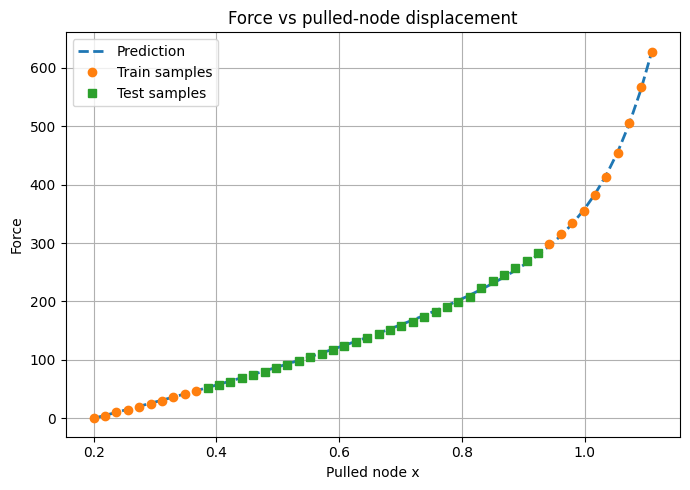

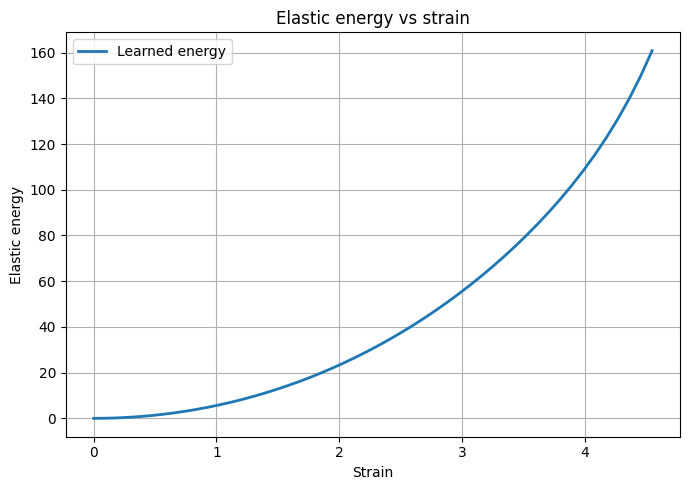

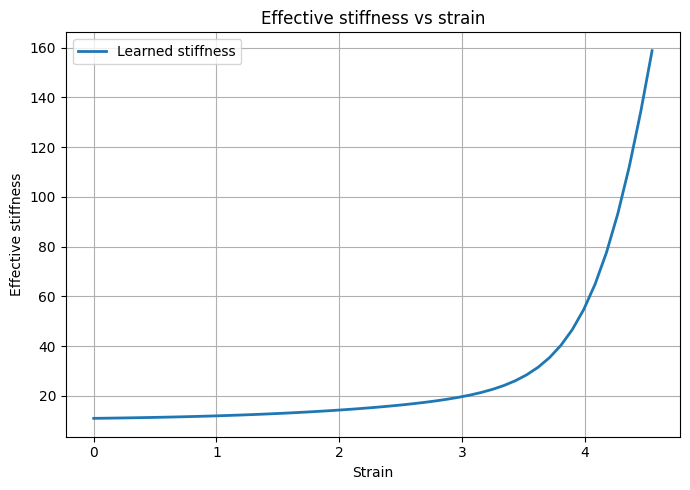

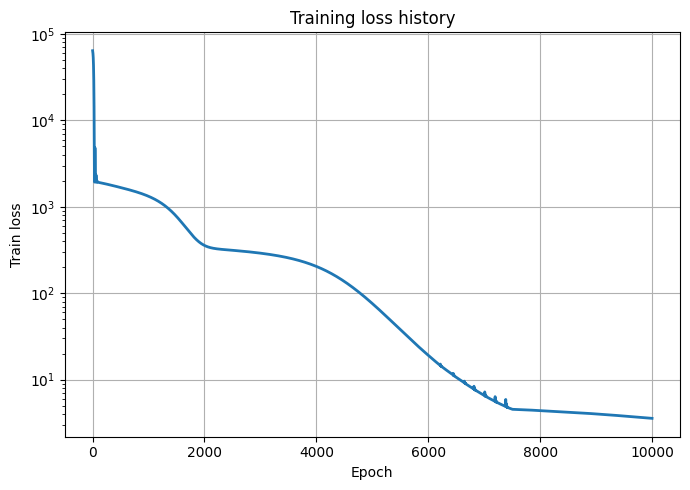

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# convert to numpy for plotting
lambdas_np = np.array(lambdas)
force_truth_np = np.array(force_truth)
pred_full_force_np = np.array(pred_full_force)
# force_truth_np = np.abs(np.array(force_truth))
# pred_full_force_np = np.abs(np.array(pred_full_force))
pulled_node_x_np = np.array(pulled_node_x)

train_mask_np = np.array(train_mask)
test_mask_np = np.array(test_mask)

# =========================================================
# 1. Force vs pulled-node displacement
# =========================================================
plt.figure(figsize=(7, 5))
# plt.plot(pulled_node_x_np, force_truth_np, "k-", linewidth=2, label="Ground truth")
plt.plot(pulled_node_x_np, pred_full_force_np, "--", linewidth=2, label="Prediction")

plt.plot(
    pulled_node_x_np[train_mask_np],
    force_truth_np[train_mask_np],
    "o",
    markersize=6,
    label="Train samples",
)
plt.plot(
    pulled_node_x_np[test_mask_np],
    force_truth_np[test_mask_np],
    "s",
    markersize=6,
    label="Test samples",
)

plt.xlabel("Pulled node x")
plt.ylabel("Force")
plt.title("Force vs pulled-node displacement")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 2. Elastic energy vs strain
# =========================================================
qs = jax.vmap(lambda lam: slinky.get_q(lam, q0))(lambdas)
strains = jax.vmap(slinky.get_eps)(qs)

# pass each scalar strain as shape (1,)
Energy = jax.vmap(lambda eps: final_model(jnp.array([eps])))(strains)

plt.figure(figsize=(7, 5))
plt.plot(np.array(strains), np.array(Energy), linewidth=2, label="Learned energy")
plt.xlabel("Strain")
plt.ylabel("Elastic energy")
plt.title("Elastic energy vs strain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# =========================================================
# 3. Stiffness vs strain
# =========================================================
stiffness = jax.vmap(
    lambda eps: jax.grad(
        lambda e: jax.grad(final_model)(jnp.array([e]))[0]
    )(eps)
)(strains)

plt.figure(figsize=(7, 5))
plt.plot(np.array(strains), np.array(stiffness), linewidth=2, label="Learned stiffness")
plt.xlabel("Strain")
plt.ylabel("Effective stiffness")
plt.title("Effective stiffness vs strain")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# =========================================================
# 3. Training loss history
# =========================================================
history_np = np.array(history)

plt.figure(figsize=(7, 5))
plt.plot(history_np, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Train loss")
plt.title("Training loss history")
plt.yscale("log")
plt.grid(True)
plt.tight_layout()
plt.show()

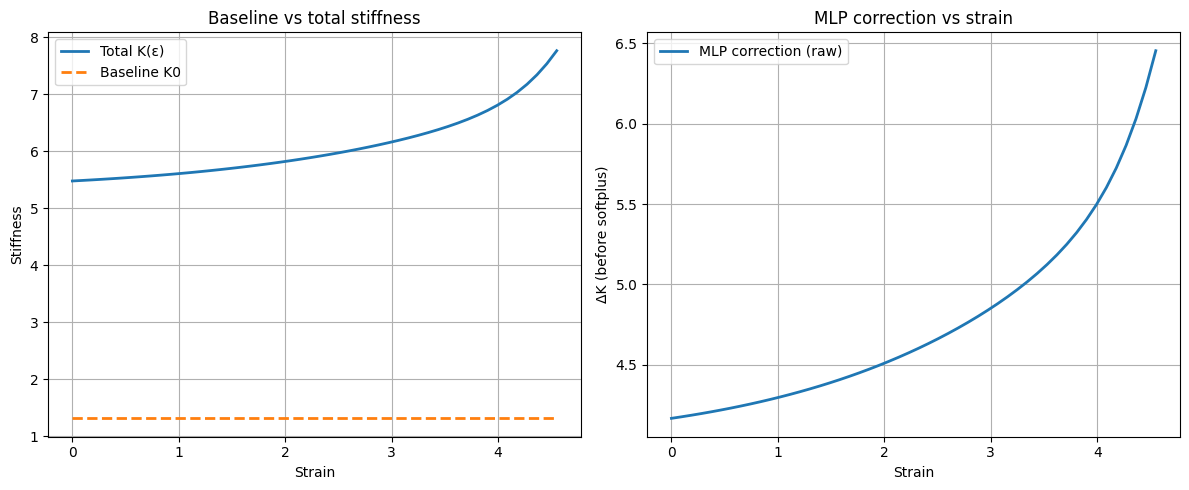

In [6]:
strain_np = np.array(strains)

def get_K_scalar(eps_scalar):
    return final_model.get_K(jnp.array([eps_scalar]))

def get_delta_scalar(eps_scalar):
    return final_model.K_mlp(jnp.array([eps_scalar]))

delta_vals = jax.vmap(get_delta_scalar)(strains)
K_total_vals = jax.vmap(get_K_scalar)(strains)

K0_val = final_model.K_baseline()
K0_vals = jnp.ones_like(K_total_vals) * K0_val

K_total_np = np.array(K_total_vals)
delta_np = np.array(delta_vals)
K0_np = np.array(K0_vals)

idx = np.argsort(strain_np)

strain_np = strain_np[idx]
K_total_np = K_total_np[idx]
delta_np = delta_np[idx]
K0_np = K0_np[idx]

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -----------------------------------
# (a) Baseline vs total stiffness
# -----------------------------------
axs[0].plot(strain_np, K_total_np, linewidth=2, label="Total K(ε)")
axs[0].plot(strain_np, K0_np, "--", linewidth=2, label="Baseline K0")
axs[0].set_xlabel("Strain")
axs[0].set_ylabel("Stiffness")
axs[0].set_title("Baseline vs total stiffness")
axs[0].legend()
axs[0].grid(True)

# -----------------------------------
# (b) MLP correction
# -----------------------------------
axs[1].plot(strain_np, delta_np, linewidth=2, label="MLP correction (raw)")
axs[1].set_xlabel("Strain")
axs[1].set_ylabel("ΔK (before softplus)")
axs[1].set_title("MLP correction vs strain")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()